# MLflow: Gestión del Ciclo de Vida de Machine Learning

## ¿Qué es MLflow?

MLflow es una plataforma de código abierto diseñada para gestionar el ciclo de vida completo de proyectos de Machine Learning. Fue desarrollado por Databricks y se ha convertido en un estándar de la industria para el seguimiento, reproducibilidad y despliegue de modelos de ML.

## ¿Por qué usar MLflow?

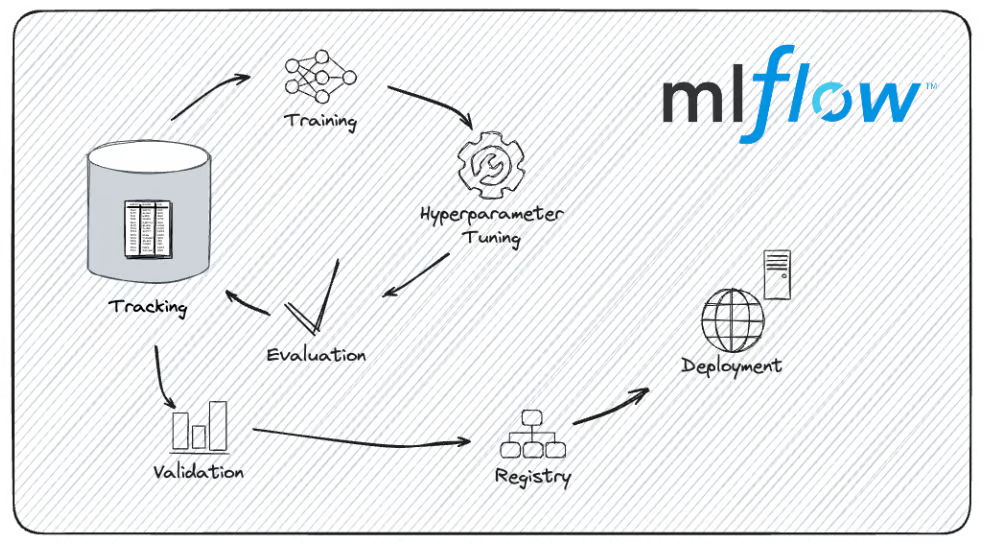

### Los 5 desafíos principales en proyectos de ML

Cuando trabajamos en proyectos de Machine Learning, nos enfrentamos a varios desafíos críticos:

**1. 🔬 Experimentación**
   - Probamos múltiples modelos, algoritmos y arquitecturas
   - Ajustamos hiperparámetros en diferentes combinaciones
   - Aplicamos diversas técnicas de preprocesamiento de datos
   - *Problema:* Difícil llevar control manual de todos los experimentos

**2. 🔄 Reproducibilidad**
   - Necesitamos recordar qué configuración exacta produjo qué resultados
   - Debemos documentar el entorno (versiones de librerías, Python, etc.)
   - *Problema:* "Funcionó hace 3 meses pero ya no sé cómo lo hice"

**3. ⚖️ Comparación**
   - Debemos comparar diferentes versiones de modelos objetivamente
   - Necesitamos visualizar métricas lado a lado
   - *Problema:* Difícil decidir cuál modelo es mejor con datos dispersos

**4. 🚀 Despliegue**
   - Pasar de un modelo experimental a producción es complicado
   - Necesitamos empaquetar el modelo con sus dependencias
   - *Problema:* "Funciona en mi máquina" pero no en producción

**5. 👥 Colaboración**
   - Compartir resultados y modelos con el equipo
   - Permitir que otros reproduzcan y mejoren nuestro trabajo
   - *Problema:* Falta de estándar para compartir experimentos

### La solución: Los 4 componentes de MLflow

MLflow resuelve estos problemas proporcionando:

**📊 MLflow Tracking**
   - Registra y consulta experimentos (parámetros, métricas, artefactos)
   - Interfaz web para visualizar y comparar resultados
   - API para registro manual o automático

**📦 MLflow Projects**
   - Empaqueta código de ML de forma reproducible
   - Define dependencias y entorno de ejecución
   - Facilita la ejecución en diferentes plataformas

**🤖 MLflow Models**
   - Gestiona y despliega modelos desde diferentes librerías
   - Formato estándar independiente del framework
   - Integración con plataformas de serving

**🏛️ MLflow Registry**
   - Almacena modelos centralizadamente con versionado
   - Gestión del ciclo de vida (staging, production, archived)
   - Control de versiones y colaboración

## Funcionamiento Básico

### Los 3 conceptos principales de MLflow

**1. 📁 Experimentos (Experiments)**
   - Contenedores para agrupar ejecuciones relacionadas
   - Ejemplo: "Clasificación de Iris", "Predicción de Precios"
   - Permiten organizar múltiples intentos del mismo problema

**2. ▶️ Ejecuciones (Runs)**
   - Cada entrenamiento de modelo individual dentro de un experimento
   - Contiene todos los detalles de una iteración específica
   - Se pueden comparar entre sí dentro del mismo experimento

**3. 📄 Artefactos (Artifacts)**
   - Archivos de salida generados durante la ejecución
   - Ejemplos: modelos entrenados, gráficos, datasets procesados, logs
   - Se almacenan y versionan automáticamente

### ¿Qué registra MLflow en cada ejecución?

En cada ejecución, MLflow captura y almacena:

**🎛️ Parámetros (Parameters)**
   - Valores de configuración del modelo
   - Ejemplos: learning rate, número de árboles, batch size
   - Son valores de entrada que definen el experimento

**📈 Métricas (Metrics)**
   - Resultados cuantitativos del modelo
   - Ejemplos: accuracy, MSE, F1-score, AUC
   - Se pueden registrar múltiples valores a lo largo del tiempo

**📦 Artefactos (Artifacts)**
   - Archivos generados durante el entrenamiento
   - El modelo serializado, gráficos, matrices de confusión
   - Cualquier archivo que queramos preservar

**🏷️ Metadatos (Metadata)**
   - Información contextual automática
   - Usuario que ejecutó, timestamp, duración
   - Versión del código (git commit), entorno de ejecución
   - Versiones de librerías y Python utilizadas

## Funcionamiento Básico

In [ ]:
# Primero instalamos MLflow si no lo tenemos instalado
%pip install mlflow

Instala dependencias adicionales:

MLflow tiene algunas dependencias opcionales para mejorar la funcionalidad. Si necesitamos utilizar funciones específicas, como la capacidad de servir modelos de MLflow, tenemos que instalar gunicorn. 

In [ ]:
%pip install gunicorn

Si utilizamos bibliotecas como TensorFlow o PyTorch, puede que tengamos que instalar sus respectivas integraciones MLflow:

In [ ]:
%pip install mlflow[extras]

Luego, sigue las instrucciones de la guía de configuración de MLflow para configurarlo.

Si solo quieres empezar rápidamente, ejecuta el siguiente código en una celda del notebook:

In [ ]:
# Importamos la librería
import mlflow
# Establecemos el experimento set.experiment nos permite crear o seleccionar un experimento existente
mlflow.set_experiment("MLflow Quickstart")

## Paso 2 - Preparar los datos de entrenamiento

Antes de entrenar nuestro primer modelo, vamos a preparar los datos de entrenamiento y los hiperparámetros del modelo.



En este ejemplo usaremos el dataset **Iris**, un conjunto de datos clásico de clasificación que contiene 150 muestras de flores iris con 4 características (longitud y ancho de sépalos y pétalos) y 3 clases diferentes.

Definiremos también los **hiperparámetros** del modelo que MLflow registrará automáticamente para poder reproducir exactamente este experimento en el futuro.


In [ ]:
# Importar las librerías necesarias
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Cargar el dataset Iris desde la librería sklearn
X, y = datasets.load_iris(return_X_y=True)

# Dividir los datos en conjuntos de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Definir los hiperparámetros del modelo
# Estos parámetros serán registrados automáticamente por MLflow
params = {
    "solver": "lbfgs",        # Algoritmo de optimización
    "max_iter": 1000,         # Número máximo de iteraciones
    "multi_class": "auto",    # Estrategia para clasificación multiclase
    "random_state": 8888,     # Semilla para reproducibilidad

}
# Imprimir información del dataset cargado
print(f"Dataset cargado: {X_train.shape[0]} muestras de entrenamiento, {X_test.shape[0]} muestras de prueba")


## Paso 3 - Entrenar un modelo con MLflow Autologging


En este paso, entrenamos el modelo con los datos de entrenamiento cargados en el paso anterior, y registramos el modelo y sus metadatos en MLflow. 

Autologging es compatible con: scikit-learn, TensorFlow, Keras, PyTorch, XGBoost, LightGBM, y más.

### Autologging: La forma más sencilla de empezar

- Información del entorno (versiones de librerías, Python, etc.)

La función de **Autologging** de MLflow es mágica: con una sola línea de código, MLflow captura automáticamente:

- El modelo entrenado como artefacto
- Todos los hiperparámetros del modelo
- Métricas de rendimiento durante el entrenamiento

In [ ]:
import mlflow

# Habilitar autologging para scikit-learn
# # Esta línea activa el registro automático de todo lo relacionado con el modelo
mlflow.sklearn.autolog()
# Entrenar el modelo normalmente - MLflow registrará todo automáticamente
lr = LogisticRegression(**params)

lr.fit(X_train, y_train)print(f"Precisión del modelo: {accuracy:.4f}")

accuracy = accuracy_score(y_test, y_pred)

# Evaluar en el conjunto de prueba y_pred = lr.predict(X_test)
print(f"Precisión del modelo: {accuracy:.4f}")


### Ventajas del Autologging

Con solo una línea de código `mlflow.sklearn.autolog()`, ahora obtienes lo mejor de ambos mundos: puedes concentrarte en entrenar el modelo, y MLflow se encargará del resto:

✅ **Guardar el modelo entrenado** como artefacto  
✅ **Registrar las métricas de rendimiento** del modelo durante el entrenamiento (precisión, exactitud, curva AUC, etc.)  
✅ **Registrar los valores de hiperparámetros** utilizados para entrenar el modelo  
✅ **Rastrear metadatos** como formato de datos de entrada, usuario, marca de tiempo, versión del código  
✅ **Capturar el entorno completo** (versiones de Python y librerías) para reproducibilidad  


Para aprender más sobre autologging y las bibliotecas compatibles, consulta la [documentación de Autologging](https://mlflow.org/docs/latest/tracking.html#automatic-logging).

## Paso 4 - Ver la ejecución en la interfaz de usuario de MLflow

- Descargar modelos y artefactos
- Examinar gráficos y visualizaciones
- Ver parámetros e hiperparámetros

MLflow proporciona una **interfaz web intuitiva** donde puedes:
- Comparar métricas entre diferentes modelos
- Visualizar todos tus experimentos y ejecuciones

Para acceder a la interfaz, ejecuta el siguiente comando en una terminal:

---

In [ ]:
# En la terminal, ejecutar el siguiente comando para iniciar la interfaz de MLflow

python -m mlflow ui --port 5000

### Navegando por la Interfaz de MLflow


Al abrir http://localhost:5000, verás la interfaz principal de MLflow con una pantalla similar a la siguiente:

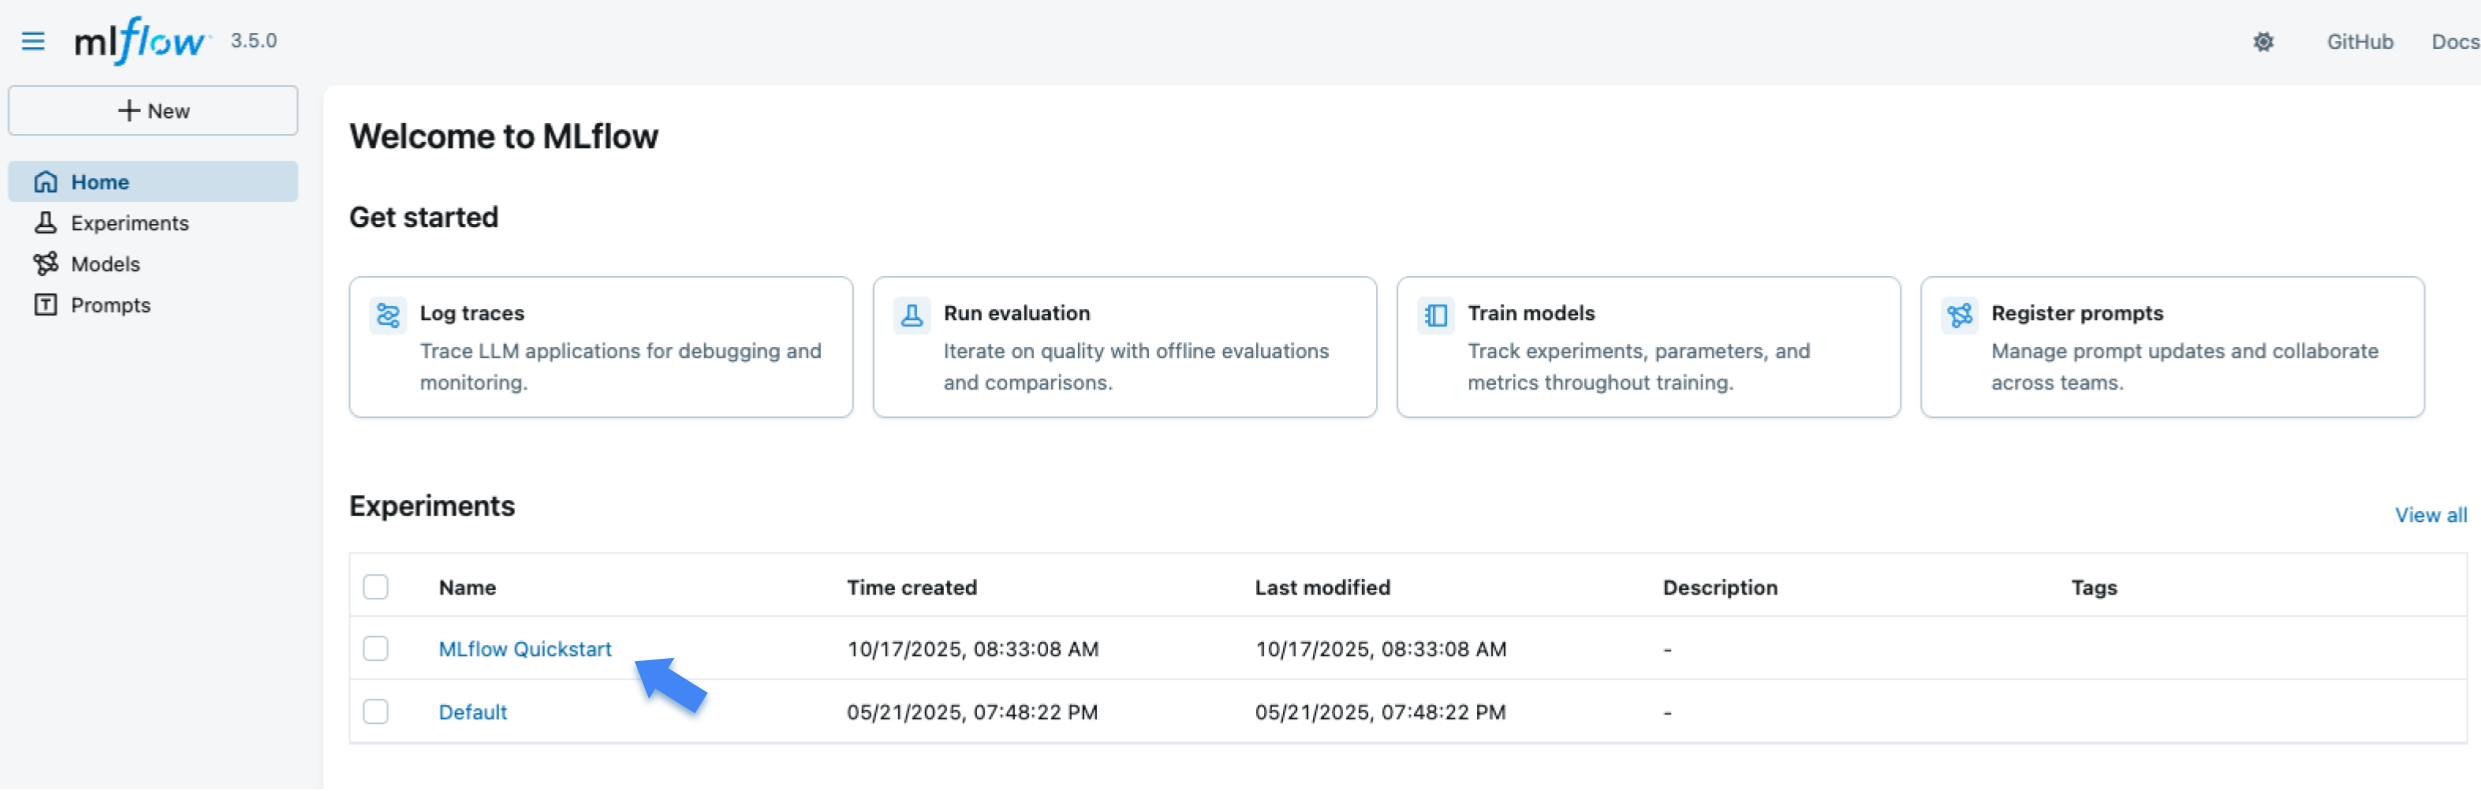

La sección "Experiments" muestra una lista de experimentos (creados recientemente). Haz clic en el experimento "MLflow Quickstart".

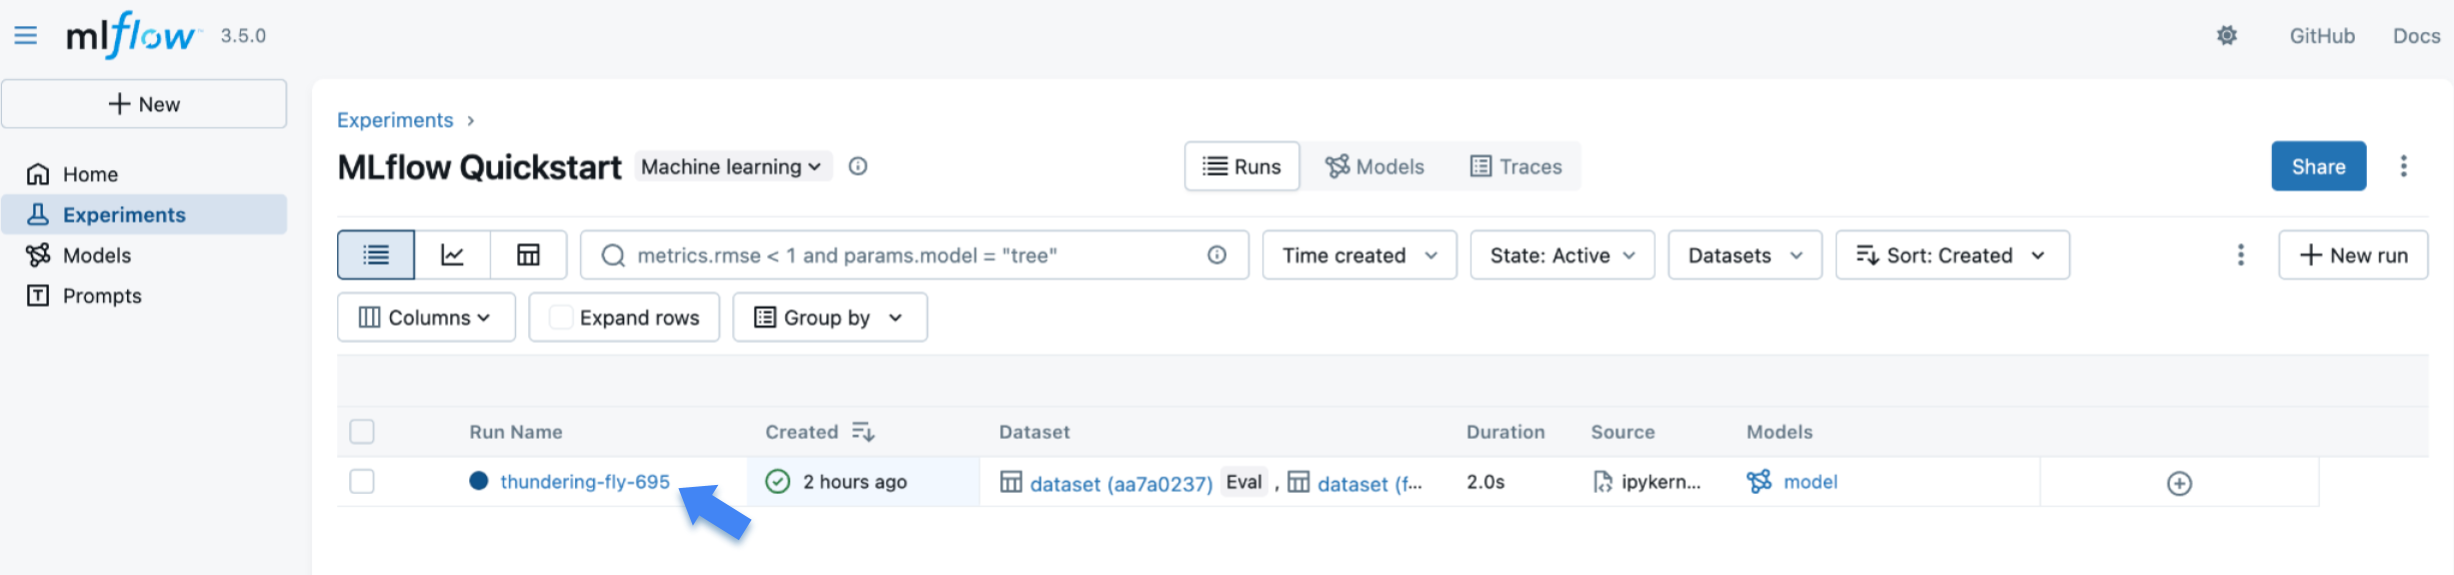

La ejecución de entrenamiento creada por MLflow aparece en la tabla. Haz clic en la ejecución para ver los detalles.


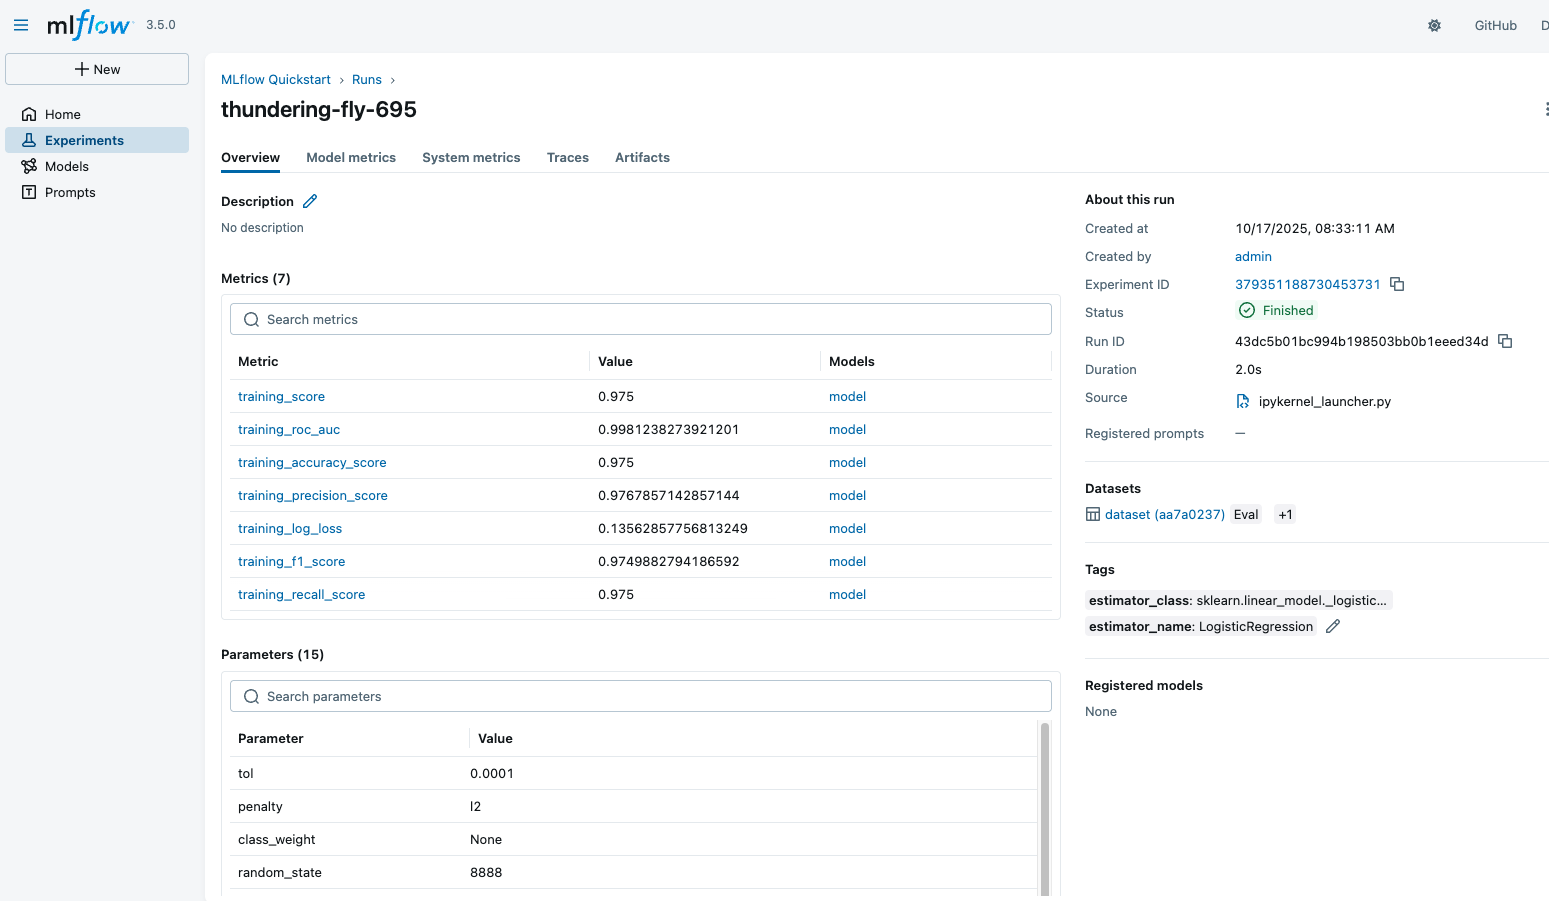

La página de detalles de la ejecución muestra un resumen de la ejecución, sus métricas registradas, hiperparámetros, etiquetas y más. Explora la interfaz de usuario para ver las diferentes vistas y funciones.

Desplázate hacia abajo hasta la sección "Model" y deberías ver el modelo que se registró durante el entrenamiento. Haz clic en el modelo para ver los detalles.



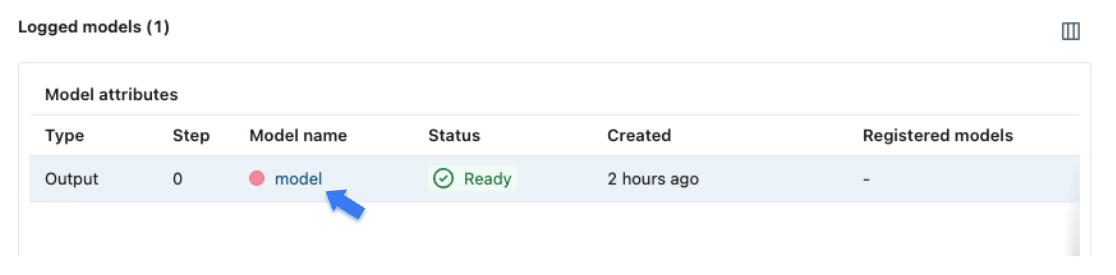

La página del modelo muestra metadatos similares como métricas de rendimiento e hiperparámetros. También incluye una sección "Artifacts" que lista los archivos que se registraron durante el entrenamiento. También puedes ver información del entorno como la versión de Python y las dependencias, que se almacenan para reproducibilidad.

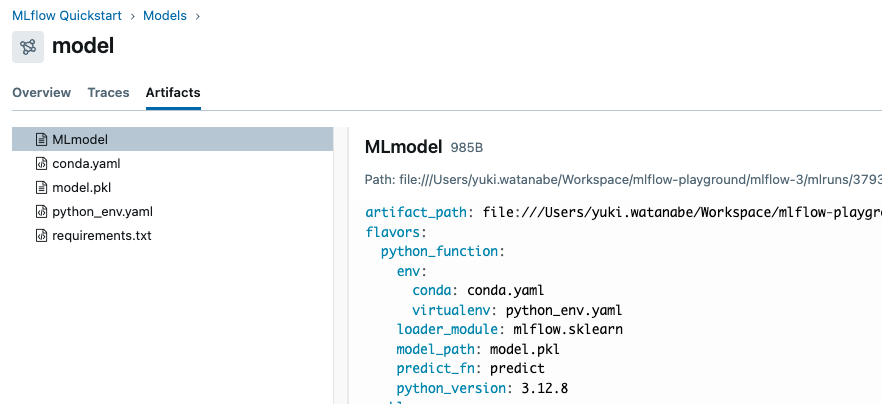

---

## Paso 5 - Registrar un modelo y metadatos manualmente

Ahora que hemos aprendido cómo registrar una ejecución de entrenamiento de modelo con MLflow autologging, vamos un paso más allá y aprendamos cómo **registrar un modelo y metadatos manualmente**. 

### ¿Cuándo usar registro manual?

El registro manual es útil cuando:

- Necesitas registrar métricas personalizadas no capturadas por autologging
- Quieres un control granular sobre qué se registra y cuándo
- Trabajas con código personalizado o modelos no estándar
- Necesitas registrar artefactos adicionales (gráficos, datasets procesados, etc.)

### Flujo de trabajo del registro manual:

El proceso sigue un orden específico para garantizar que todo se registre correctamente:

1. **Iniciar un contexto de ejecución** con `mlflow.start_run()`
   - Crea una nueva "run" donde se registrará todo
   - Todo lo que esté dentro del contexto `with` se asocia a esta ejecución

2. **Registrar parámetros** con `mlflow.log_params()`
   - Registra los hiperparámetros ANTES de entrenar
   - Permite reproducir exactamente el experimento

3. **Entrenar el modelo**
   - Entrenar normalmente con los parámetros definidos
   - No hay diferencia con el código habitual de entrenamiento

4. **Hacer predicciones y calcular métricas**
   - Evaluar el modelo en el conjunto de prueba
   - Calcular todas las métricas que queremos registrar

5. **Registrar métricas** con `mlflow.log_metric()`
   - Guardar los resultados numéricos del rendimiento
   - Se pueden registrar múltiples métricas

6. **Guardar el modelo** con `mlflow.sklearn.log_model()`
   - Serializa y guarda el modelo entrenado
   - Devuelve información sobre dónde se guardó

7. **Etiquetar la ejecución** con `mlflow.set_tag()`
   - Añade metadatos descriptivos para organización
   - Facilita búsquedas y filtrado posterior

Veamos un ejemplo completo siguiendo este flujo:

In [ ]:
# Iniciar una ejecución de MLflow
# Todo lo que esté dentro de este contexto será registrado en la misma ejecución
with mlflow.start_run():
    
    # PASO 1: Registrar los hiperparámetros
    # ----------------------------------------
    # Esto nos permite saber exactamente qué configuración usamos
    # IMPORTANTE: Los parámetros se registran ANTES de entrenar
    mlflow.log_params(params)
    print("✅ Paso 1: Parámetros registrados")

    # PASO 2: Entrenar el modelo
    # ----------------------------------------
    # Entrenamos el modelo normalmente usando los parámetros definidos
    lr = LogisticRegression(**params)
    lr.fit(X_train, y_train)
    print("✅ Paso 2: Modelo entrenado")

    # PASO 3: Hacer predicciones en el conjunto de prueba
    # ----------------------------------------
    # Necesitamos las predicciones para calcular las métricas
    y_pred = lr.predict(X_test)
    print("✅ Paso 3: Predicciones realizadas")
    
    # PASO 4: Calcular múltiples métricas
    # ----------------------------------------
    # Evaluamos el rendimiento del modelo desde diferentes perspectivas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print("✅ Paso 4: Métricas calculadas")

    # PASO 5: Registrar todas las métricas
    # ----------------------------------------
    # Guardamos los resultados numéricos en MLflow
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    print("✅ Paso 5: Métricas registradas en MLflow")

    # PASO 6: Guardar el modelo entrenado como artefacto
    # ----------------------------------------
    # model_info contiene la URI donde se guardó el modelo
    model_info = mlflow.sklearn.log_model(sk_model=lr, artifact_path="iris_model")
    print("✅ Paso 6: Modelo guardado como artefacto")

    # PASO 7: Establecer etiquetas (tags) para organización y búsqueda
    # ----------------------------------------
    # Las etiquetas nos ayudan a organizar y filtrar experimentos
    mlflow.set_tag("Training Info", "Modelo LR básico para clasificación Iris")
    mlflow.set_tag("modelo", "LogisticRegression")
    mlflow.set_tag("dataset", "Iris")
    print("✅ Paso 7: Etiquetas añadidas")
    
    # Imprimir resumen de resultados
    print("\n" + "="*50)
    print("📊 RESUMEN DE LA EJECUCIÓN")
    print("="*50)
    print(f"Modelo registrado exitosamente")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"URI del modelo: {model_info.model_uri}")
    print("="*50)

---

## Paso 6 - Cargar el modelo para inferencia

Una de las ventajas principales de MLflow es que **separa el entrenamiento del despliegue**. Una vez que el modelo está registrado, podemos cargarlo en cualquier momento para hacer predicciones, incluso en un entorno diferente.

### Dos formas de cargar modelos:

MLflow ofrece dos métodos principales para cargar modelos registrados, cada uno con sus propias ventajas:

#### 1. **Formato pyfunc (Python Function)** - Recomendado para producción
   
   ```python
   loaded_model = mlflow.pyfunc.load_model(model_uri)
   ```
   
   **Ventajas:**
   - ✅ Formato genérico compatible con **cualquier framework** (sklearn, TensorFlow, PyTorch, etc.)
   - ✅ Interfaz estándar independiente de la librería original
   - ✅ Ideal para **despliegue y serving** en producción
   - ✅ Facilita cambiar entre frameworks sin modificar código de inferencia

#### 2. **Formato nativo** - Útil para desarrollo
   
   ```python
   loaded_model = mlflow.sklearn.load_model(model_uri)
   ```
   
   **Ventajas:**
   - ✅ Carga como objeto nativo de la librería (ej: objeto scikit-learn completo)
   - ✅ Acceso completo a **métodos específicos** del modelo original
   - ✅ Útil para **desarrollo e inspección** detallada del modelo
   - ✅ Permite usar funcionalidades avanzadas de la librería

---

### Ejemplo práctico con formato pyfunc

En este ejemplo usaremos el formato **pyfunc** que es más versátil para producción:

In [ ]:
# Cargar el modelo como una función Python genérica
# Esto simula cómo cargaríamos el modelo en producción
loaded_model = mlflow.pyfunc.load_model(model_info.model_uri)

# Hacer predicciones con el modelo cargado
predictions = loaded_model.predict(X_test)

# Obtener los nombres de las características para mejor presentación
iris_feature_names = datasets.load_iris().feature_names
iris_target_names = datasets.load_iris().target_names

# Crear un DataFrame con los resultados

result = pd.DataFrame(X_test, columns=iris_feature_names)
result.head(10)

result["clase_real"] = y_test

result["clase_predicha"] = predictions
print(f"\nPrecisión total: {accuracy:.2f}%")

result["nombre_real"] = [iris_target_names[i] for i in y_test]
accuracy = (result["correcto"].sum() / len(result)) * 100

result["nombre_predicho"] = [iris_target_names[int(i)] for i in predictions]# Calcular precisión

result["correcto"] = result["clase_real"] == result["clase_predicha"]

print(result[["nombre_real", "nombre_predicho", "correcto"]].head(10))

# Mostrar las primeras predicciones
print("\n=== Primeras 10 predicciones ===")

La salida de este código se verá algo así:

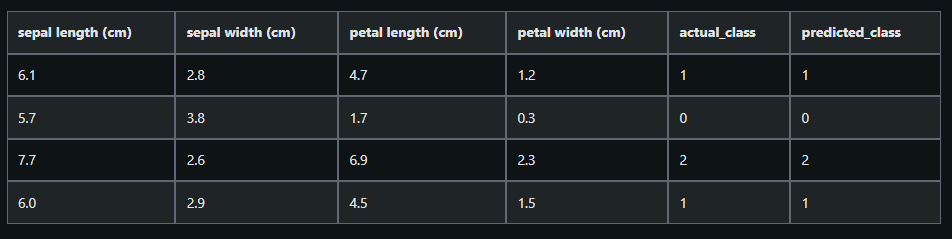

---
---

# 🎯 Ejemplo Completo: Proyecto de Clasificación de Diabetes

## Proyecto End-to-End con MLflow

En esta sección, desarrollaremos un **proyecto completo de Machine Learning** desde cero hasta el despliegue, utilizando MLflow en cada paso del proceso. Este ejemplo te mostrará cómo aplicar MLflow en un caso real del mundo profesional.

### 📋 Descripción del Proyecto

**Objetivo**: Predecir si un paciente tiene diabetes basándose en características clínicas

**Dataset**: Diabetes dataset de scikit-learn
- 442 pacientes
- 10 características (edad, sexo, IMC, presión arterial, etc.)
- Variable objetivo: Medida cuantitativa de progresión de diabetes

**Pipeline completo**:
1. 📊 Análisis exploratorio y preparación de datos
2. 🔬 Experimentación con múltiples modelos
3. 🎯 Optimización de hiperparámetros
4. 📦 Registro en MLflow Model Registry
5. 🚀 Simulación de despliegue

---

## Fase 1: Configuración Inicial y Exploración de Datos

In [ ]:
# Importar todas las librerías necesarias
import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Modelos a probar
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Configurar estilo de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Librerías importadas correctamente")

### Cargar y Explorar el Dataset

In [ ]:
# Cargar el dataset de diabetes
diabetes = datasets.load_diabetes()
X = diabetes.data
y = diabetes.target

# Crear DataFrame para mejor manipulación
feature_names = diabetes.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print("="*60)
print("📊 INFORMACIÓN DEL DATASET DE DIABETES")
print("="*60)
print(f"\n📌 Tamaño del dataset: {df.shape}")
print(f"📌 Número de muestras: {len(df)}")
print(f"📌 Número de características: {len(feature_names)}")
print(f"\n📌 Características disponibles:")
for i, feat in enumerate(feature_names, 1):
    print(f"   {i}. {feat}")

print(f"\n📌 Estadísticas de la variable objetivo:")
print(f"   - Mínimo: {y.min():.2f}")
print(f"   - Máximo: {y.max():.2f}")
print(f"   - Media: {y.mean():.2f}")
print(f"   - Mediana: {np.median(y):.2f}")

print("\n📌 Primeras 5 muestras:")
print(df.head())

print("\n📌 Resumen estadístico:")
print(df.describe())

### Preparación de Datos

In [ ]:
# Dividir datos: 70% entrenamiento, 15% validación, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42  # 0.176 de 0.85 ≈ 0.15 del total
)

# Normalizar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("✅ División de datos completada:")
print(f"   - Conjunto de entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   - Conjunto de validación: {X_val.shape[0]} muestras ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   - Conjunto de test: {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\n✅ Datos normalizados con StandardScaler")

---

## Fase 2: Experimentación con Múltiples Modelos

Entrenaremos varios modelos y los registraremos todos en MLflow para comparación.

In [ ]:
# Configurar experimento en MLflow
experiment_name = "Diabetes_Prediction_Project"
mlflow.set_experiment(experiment_name)

print(f"🔬 Experimento configurado: '{experiment_name}'")
print(f"📁 Los resultados se guardarán en: ./mlruns/")

### Función auxiliar para entrenar y registrar modelos

In [ ]:
def train_and_log_model(model, model_name, params, X_train, y_train, X_val, y_val):
    """
    Entrena un modelo y registra todos los detalles en MLflow
    
    Parameters:
    -----------
    model : sklearn estimator
        Modelo a entrenar
    model_name : str
        Nombre descriptivo del modelo
    params : dict
        Hiperparámetros del modelo
    """
    
    with mlflow.start_run(run_name=model_name):
        
        # Registrar parámetros
        mlflow.log_params(params)
        
        # Entrenar modelo
        model.fit(X_train, y_train)
        
        # Predicciones
        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
        
        # Calcular métricas para conjunto de entrenamiento
        train_mse = mean_squared_error(y_train, y_pred_train)
        train_rmse = np.sqrt(train_mse)
        train_mae = mean_absolute_error(y_train, y_pred_train)
        train_r2 = r2_score(y_train, y_pred_train)
        
        # Calcular métricas para conjunto de validación
        val_mse = mean_squared_error(y_val, y_pred_val)
        val_rmse = np.sqrt(val_mse)
        val_mae = mean_absolute_error(y_val, y_pred_val)
        val_r2 = r2_score(y_val, y_pred_val)
        
        # Registrar métricas en MLflow
        mlflow.log_metrics({
            "train_mse": train_mse,
            "train_rmse": train_rmse,
            "train_mae": train_mae,
            "train_r2": train_r2,
            "val_mse": val_mse,
            "val_rmse": val_rmse,
            "val_mae": val_mae,
            "val_r2": val_r2
        })
        
        # Registrar modelo
        mlflow.sklearn.log_model(model, "model")
        
        # Registrar tags
        mlflow.set_tag("model_type", model_name)
        mlflow.set_tag("dataset", "Diabetes")
        mlflow.set_tag("phase", "Experimentación")
        
        # Crear y guardar gráfico de predicciones vs reales
        plt.figure(figsize=(10, 5))
        
        plt.subplot(1, 2, 1)
        plt.scatter(y_train, y_pred_train, alpha=0.5)
        plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
        plt.xlabel('Valores Reales')
        plt.ylabel('Predicciones')
        plt.title(f'{model_name} - Entrenamiento')
        
        plt.subplot(1, 2, 2)
        plt.scatter(y_val, y_pred_val, alpha=0.5, color='green')
        plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
        plt.xlabel('Valores Reales')
        plt.ylabel('Predicciones')
        plt.title(f'{model_name} - Validación')
        
        plt.tight_layout()
        plt.savefig(f"{model_name}_predictions.png")
        mlflow.log_artifact(f"{model_name}_predictions.png")
        plt.close()
        
        # Imprimir resultados
        print(f"\n{'='*60}")
        print(f"✅ {model_name} - Entrenamiento completado")
        print(f"{'='*60}")
        print(f"📊 Métricas de Entrenamiento:")
        print(f"   - RMSE: {train_rmse:.2f}")
        print(f"   - MAE:  {train_mae:.2f}")
        print(f"   - R²:   {train_r2:.4f}")
        print(f"\n📊 Métricas de Validación:")
        print(f"   - RMSE: {val_rmse:.2f}")
        print(f"   - MAE:  {val_mae:.2f}")
        print(f"   - R²:   {val_r2:.4f}")
        
        return val_r2, val_rmse

print("✅ Función auxiliar creada")

### Entrenar múltiples modelos

In [ ]:
# Diccionario para almacenar resultados
results = {}

print("\n" + "="*60)
print("🚀 INICIANDO EXPERIMENTACIÓN CON MÚLTIPLES MODELOS")
print("="*60)

# 1. Ridge Regression
print("\n🔹 Modelo 1/5: Ridge Regression")
ridge_params = {"alpha": 1.0, "random_state": 42}
ridge_model = Ridge(**ridge_params)
r2, rmse = train_and_log_model(
    ridge_model, "Ridge_Regression", ridge_params,
    X_train_scaled, y_train, X_val_scaled, y_val
)
results["Ridge"] = {"r2": r2, "rmse": rmse}

# 2. Lasso Regression
print("\n🔹 Modelo 2/5: Lasso Regression")
lasso_params = {"alpha": 1.0, "random_state": 42}
lasso_model = Lasso(**lasso_params)
r2, rmse = train_and_log_model(
    lasso_model, "Lasso_Regression", lasso_params,
    X_train_scaled, y_train, X_val_scaled, y_val
)
results["Lasso"] = {"r2": r2, "rmse": rmse}

# 3. ElasticNet
print("\n🔹 Modelo 3/5: ElasticNet")
elastic_params = {"alpha": 1.0, "l1_ratio": 0.5, "random_state": 42}
elastic_model = ElasticNet(**elastic_params)
r2, rmse = train_and_log_model(
    elastic_model, "ElasticNet", elastic_params,
    X_train_scaled, y_train, X_val_scaled, y_val
)
results["ElasticNet"] = {"r2": r2, "rmse": rmse}

# 4. Random Forest
print("\n🔹 Modelo 4/5: Random Forest")
rf_params = {"n_estimators": 100, "max_depth": 10, "random_state": 42}
rf_model = RandomForestRegressor(**rf_params)
r2, rmse = train_and_log_model(
    rf_model, "Random_Forest", rf_params,
    X_train_scaled, y_train, X_val_scaled, y_val
)
results["Random Forest"] = {"r2": r2, "rmse": rmse}

# 5. Gradient Boosting
print("\n🔹 Modelo 5/5: Gradient Boosting")
gb_params = {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 3, "random_state": 42}
gb_model = GradientBoostingRegressor(**gb_params)
r2, rmse = train_and_log_model(
    gb_model, "Gradient_Boosting", gb_params,
    X_train_scaled, y_train, X_val_scaled, y_val
)
results["Gradient Boosting"] = {"r2": r2, "rmse": rmse}

print("\n" + "="*60)
print("✅ EXPERIMENTACIÓN COMPLETADA")
print("="*60)

### Comparación de Resultados

In [ ]:
# Crear DataFrame con resultados
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('r2', ascending=False)

print("\n" + "="*60)
print("📊 TABLA COMPARATIVA DE MODELOS")
print("="*60)
print(results_df.to_string())

# Visualizar comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² Score
results_df['r2'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('R² Score')
axes[0].set_title('Comparación de R² Score (Mayor es Mejor)')
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Umbral 0.5')
axes[0].legend()

# RMSE
results_df['rmse'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_xlabel('RMSE')
axes[1].set_title('Comparación de RMSE (Menor es Mejor)')

plt.tight_layout()
plt.savefig("model_comparison.png")
print("\n✅ Gráfico de comparación guardado: model_comparison.png")
plt.show()

# Identificar el mejor modelo
best_model_name = results_df.index[0]
best_r2 = results_df.iloc[0]['r2']
best_rmse = results_df.iloc[0]['rmse']

print(f"\n🏆 MEJOR MODELO: {best_model_name}")
print(f"   - R² Score: {best_r2:.4f}")
print(f"   - RMSE: {best_rmse:.2f}")

---

## Fase 3: Optimización del Mejor Modelo

Ahora optimizaremos el mejor modelo usando Grid Search.

In [ ]:
# Optimización con GridSearch para Gradient Boosting (generalmente el mejor)
print("\n" + "="*60)
print("🔧 OPTIMIZACIÓN DE HIPERPARÁMETROS")
print("="*60)
print(f"\nOptimizando: Gradient Boosting Regressor")

# Definir grid de parámetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5]
}

# Realizar Grid Search
gb_model = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(
    gb_model, 
    param_grid, 
    cv=5, 
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("\n⏳ Entrenando... esto puede tomar unos minutos...")
grid_search.fit(X_train_scaled, y_train)

print(f"\n✅ Optimización completada")
print(f"\n🎯 Mejores parámetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"   - {param}: {value}")

# Registrar el modelo optimizado en MLflow
with mlflow.start_run(run_name="Gradient_Boosting_OPTIMIZED"):
    
    # Registrar mejores parámetros
    mlflow.log_params(grid_search.best_params_)
    
    # Obtener el mejor modelo
    best_model = grid_search.best_estimator_
    
    # Predicciones
    y_pred_train = best_model.predict(X_train_scaled)
    y_pred_val = best_model.predict(X_val_scaled)
    y_pred_test = best_model.predict(X_test_scaled)
    
    # Métricas de validación
    val_mse = mean_squared_error(y_val, y_pred_val)
    val_rmse = np.sqrt(val_mse)
    val_mae = mean_absolute_error(y_val, y_pred_val)
    val_r2 = r2_score(y_val, y_pred_val)
    
    # Métricas de test (evaluación final)
    test_mse = mean_squared_error(y_test, y_pred_test)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)
    
    # Registrar todas las métricas
    mlflow.log_metrics({
        "val_mse": val_mse,
        "val_rmse": val_rmse,
        "val_mae": val_mae,
        "val_r2": val_r2,
        "test_mse": test_mse,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "test_r2": test_r2,
        "cv_best_score": grid_search.best_score_
    })
    
    # Registrar modelo
    model_info = mlflow.sklearn.log_model(
        best_model, 
        "model",
        registered_model_name="diabetes-prediction-model"
    )
    
    # Registrar el scaler también (importante para producción)
    import joblib
    joblib.dump(scaler, "scaler.pkl")
    mlflow.log_artifact("scaler.pkl")
    
    # Tags
    mlflow.set_tag("model_type", "Gradient_Boosting_Optimized")
    mlflow.set_tag("dataset", "Diabetes")
    mlflow.set_tag("phase", "Producción")
    mlflow.set_tag("status", "Champion")
    
    print("\n" + "="*60)
    print("📊 RESULTADOS DEL MODELO OPTIMIZADO")
    print("="*60)
    print(f"\n📈 Métricas de Validación:")
    print(f"   - RMSE: {val_rmse:.2f}")
    print(f"   - MAE:  {val_mae:.2f}")
    print(f"   - R²:   {val_r2:.4f}")
    print(f"\n📈 Métricas de Test (Evaluación Final):")
    print(f"   - RMSE: {test_rmse:.2f}")
    print(f"   - MAE:  {test_mae:.2f}")
    print(f"   - R²:   {test_r2:.4f}")
    print(f"\n✅ Modelo registrado en MLflow Model Registry")
    print(f"📦 Nombre del modelo: diabetes-prediction-model")
    print(f"🔗 URI del modelo: {model_info.model_uri}")

---

## Fase 4: Simulación de Despliegue

Ahora simularemos cómo se usaría este modelo en producción.

### Cargar el modelo desde MLflow

In [ ]:
print("\n" + "="*60)
print("🚀 SIMULACIÓN DE DESPLIEGUE EN PRODUCCIÓN")
print("="*60)

# Cargar el modelo registrado
model_name = "diabetes-prediction-model"
model_version = 1

# Cargar modelo como pyfunc (formato genérico para producción)
model_uri = f"models:/{model_name}/{model_version}"
loaded_model = mlflow.pyfunc.load_model(model_uri)

print(f"\n✅ Modelo cargado desde MLflow Registry")
print(f"   - Nombre: {model_name}")
print(f"   - Versión: {model_version}")
print(f"   - URI: {model_uri}")

### Función de predicción para producción

In [ ]:
def predict_diabetes_progression(patient_data, model, scaler):
    """
    Función de predicción para usar en producción
    
    Parameters:
    -----------
    patient_data : dict o DataFrame
        Datos del paciente con las 10 características
    model : mlflow model
        Modelo cargado desde MLflow
    scaler : sklearn scaler
        Scaler usado en entrenamiento
    
    Returns:
    --------
    dict : Predicción y detalles
    """
    
    # Convertir a DataFrame si es diccionario
    if isinstance(patient_data, dict):
        patient_df = pd.DataFrame([patient_data])
    else:
        patient_df = patient_data
    
    # Normalizar datos
    patient_scaled = scaler.transform(patient_df)
    
    # Hacer predicción
    prediction = model.predict(patient_scaled)[0]
    
    # Interpretar resultado
    if prediction < 100:
        risk_level = "Bajo"
        color = "🟢"
    elif prediction < 200:
        risk_level = "Moderado"
        color = "🟡"
    else:
        risk_level = "Alto"
        color = "🔴"
    
    return {
        "prediction": float(prediction),
        "risk_level": risk_level,
        "color": color
    }

print("✅ Función de predicción creada")

### Ejemplo de predicción en producción

In [ ]:
# Cargar el scaler
import joblib
scaler_loaded = joblib.load("scaler.pkl")

# Crear ejemplos de pacientes para predicción
ejemplo_pacientes = [
    {
        "age": 0.05,
        "sex": 0.05,
        "bmi": 0.06,
        "bp": 0.02,
        "s1": -0.04,
        "s2": -0.03,
        "s3": -0.01,
        "s4": -0.03,
        "s5": 0.00,
        "s6": 0.02
    },
    {
        "age": 0.08,
        "sex": 0.05,
        "bmi": 0.12,
        "bp": 0.08,
        "s1": 0.06,
        "s2": 0.05,
        "s3": 0.04,
        "s4": 0.07,
        "s5": 0.09,
        "s6": 0.08
    }
]

print("\n" + "="*60)
print("🏥 PREDICCIONES EN PRODUCCIÓN")
print("="*60)

for i, paciente in enumerate(ejemplo_pacientes, 1):
    resultado = predict_diabetes_progression(paciente, loaded_model, scaler_loaded)
    
    print(f"\n{resultado['color']} Paciente {i}:")
    print(f"   - Predicción: {resultado['prediction']:.2f}")
    print(f"   - Nivel de Riesgo: {resultado['risk_level']}")

# Predicción en batch (múltiples pacientes)
print("\n" + "-"*60)
print("📊 Predicción en Batch:")

# Usar datos de test como ejemplo
batch_predictions = loaded_model.predict(X_test_scaled)

print(f"   - Total de pacientes procesados: {len(batch_predictions)}")
print(f"   - Predicción promedio: {np.mean(batch_predictions):.2f}")
print(f"   - Predicción mínima: {np.min(batch_predictions):.2f}")
print(f"   - Predicción máxima: {np.max(batch_predictions):.2f}")

---

## Fase 5: Monitoreo y Resumen del Proyecto

### Visualización del ciclo completo

In [ ]:
# Crear visualización del rendimiento final
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Predicciones vs Reales (Test Set)
axes[0, 0].scatter(y_test, y_pred_test, alpha=0.6, s=50)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Predicción Perfecta')
axes[0, 0].set_xlabel('Valores Reales', fontsize=12)
axes[0, 0].set_ylabel('Predicciones', fontsize=12)
axes[0, 0].set_title('Predicciones vs Valores Reales (Test Set)', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribución de errores
residuals = y_test - y_pred_test
axes[0, 1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Residuales', fontsize=12)
axes[0, 1].set_ylabel('Frecuencia', fontsize=12)
axes[0, 1].set_title('Distribución de Errores', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Importancia de características
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=True)
    
    axes[1, 0].barh(importance_df['feature'], importance_df['importance'])
    axes[1, 0].set_xlabel('Importancia', fontsize=12)
    axes[1, 0].set_title('Importancia de Características', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Métricas finales
metrics_text = f"""
MÉTRICAS FINALES DEL MODELO

Conjunto de Test:
• R² Score: {test_r2:.4f}
• RMSE: {test_rmse:.2f}
• MAE: {test_mae:.2f}

Modelo: Gradient Boosting Optimizado
Parámetros optimizados: Sí
Registrado en MLflow: Sí
Estado: Listo para Producción ✅
"""

axes[1, 1].text(0.1, 0.5, metrics_text, fontsize=11, 
                verticalalignment='center', family='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')

plt.suptitle('📊 Resumen del Proyecto de Clasificación de Diabetes', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig("final_project_summary.png", dpi=300, bbox_inches='tight')
print("\n✅ Visualización del proyecto guardada: final_project_summary.png")
plt.show()

### Resumen Final del Proyecto

In [ ]:
print("\n" + "="*70)
print(" "*20 + "🎉 PROYECTO COMPLETADO 🎉")
print("="*70)

# Clasificación más realista de la capacidad predictiva
def clasificar_r2(r2_score):
    """Clasifica la capacidad predictiva basada en R² Score"""
    if r2_score >= 0.9:
        return "Excelente ⭐⭐⭐⭐⭐", f"El modelo explica el {r2_score*100:.1f}% de la varianza"
    elif r2_score >= 0.7:
        return "Muy Buena ⭐⭐⭐⭐", f"El modelo explica el {r2_score*100:.1f}% de la varianza"
    elif r2_score >= 0.5:
        return "Buena ⭐⭐⭐", f"El modelo explica el {r2_score*100:.1f}% de la varianza"
    elif r2_score >= 0.3:
        return "Moderada ⭐⭐", f"El modelo explica solo el {r2_score*100:.1f}% de la varianza"
    else:
        return "Limitada ⭐", f"El modelo explica solo el {r2_score*100:.1f}% de la varianza"

capacidad, explicacion = clasificar_r2(test_r2)

print(f"""
📁 DETALLES DEL PROYECTO
{'─'*70}
Proyecto: Predicción de Progresión de Diabetes
Dataset: Diabetes (sklearn) - 442 pacientes
Características: 10 variables clínicas

📊 EXPERIMENTACIÓN
{'─'*70}
Modelos probados: 5 (Ridge, Lasso, ElasticNet, Random Forest, GB)
Mejor modelo base: {best_model_name}
Optimización: Grid Search con validación cruzada
Modelo final: Gradient Boosting Optimizado

📈 RESULTADOS FINALES
{'─'*70}
R² Score (Test): {test_r2:.4f}
RMSE (Test): {test_rmse:.2f}
MAE (Test): {test_mae:.2f}

Capacidad predictiva: {capacidad}
└─ {explicacion}
└─ En promedio, el error es de ±{test_mae:.1f} unidades
└─ Nota: Para problemas médicos complejos, R² > 0.4 es aceptable

📊 INTERPRETACIÓN DE LAS MÉTRICAS
{'─'*70}
R² Score (Coeficiente de Determinación):
  • Rango: 0 a 1 (puede ser negativo si el modelo es muy malo)
  • {test_r2:.1%} de la variabilidad en la progresión de diabetes es explicada
  • {100-test_r2*100:.1f}% de la variabilidad NO es capturada por el modelo
  
RMSE (Error Cuadrático Medio):
  • Penaliza más los errores grandes
  • Valor: {test_rmse:.2f} en la escala original de la variable objetivo
  
MAE (Error Absoluto Medio):
  • Error promedio en términos absolutos
  • En promedio, las predicciones se desvían ±{test_mae:.2f} unidades

🔧 COMPONENTES DE MLFLOW UTILIZADOS
{'─'*70}
✅ MLflow Tracking - Seguimiento de experimentos
✅ MLflow Models - Registro y versionado de modelos
✅ MLflow Registry - Registro centralizado
✅ Artifacts - Gráficos y scaler guardados

🚀 ESTADO DE DESPLIEGUE
{'─'*70}
Modelo registrado: Sí
Nombre: diabetes-prediction-model
Versión: 1
Scaler guardado: Sí
Función de predicción: Lista
Estado: {'✅ LISTO PARA PRODUCCIÓN' if test_r2 > 0.5 else '⚠️ REQUIERE VALIDACIÓN CLÍNICA'}

📝 PRÓXIMOS PASOS RECOMENDADOS
{'─'*70}
1. Monitorear el rendimiento del modelo en producción
2. Reentrenar periódicamente con nuevos datos
3. Implementar A/B testing con nuevas versiones
4. Configurar alertas de degradación del modelo
5. Documentar el API de predicción para el equipo
6. {'Validar con expertos médicos antes de uso clínico' if test_r2 < 0.6 else 'Realizar pruebas piloto en entorno controlado'}

💡 APRENDIZAJES CLAVE
{'─'*70}
• MLflow facilita la experimentación sistemática
• El registro automático acelera el desarrollo
• La comparación visual ayuda en la toma de decisiones
• El Model Registry simplifica el despliegue
• La reproducibilidad es clave en ML
• Un R² < 0.5 sugiere que hay factores no capturados por el modelo
• En problemas médicos, validación clínica es fundamental

{'='*70}
""")

print("\n🎓 ¡Has completado un proyecto end-to-end de Machine Learning con MLflow!")
print("🔗 Revisa la interfaz de MLflow en: http://localhost:5000")
print("\n✨ Para ejecutar el servidor MLflow, usa: python -m mlflow ui --port 5000")

---

# 🚀 Despliegue del Modelo en Producción

## ¿Qué es el Despliegue de Modelos?

El **despliegue** es el proceso de poner un modelo de Machine Learning en un entorno de producción donde puede recibir solicitudes y devolver predicciones en tiempo real. Es el paso crítico que convierte un modelo experimental en una aplicación útil.

### Opciones de Despliegue con MLflow

MLflow proporciona múltiples formas de desplegar modelos:

**1. 🌐 REST API con MLflow Models Serve**
   - Crea un servidor HTTP que expone el modelo como API
   - Usa **gunicorn** como servidor WSGI para producción
   - Ideal para aplicaciones web y microservicios

**2. 🐳 Contenedores Docker**
   - Empaqueta el modelo en una imagen Docker
   - Portabilidad completa entre entornos
   - Facilita escalado y orquestación

**3. ☁️ Plataformas Cloud**
   - AWS SageMaker, Azure ML, Google Cloud AI
   - MLflow se integra nativamente
   - Escalado automático y gestión simplificada

**4. 📊 Batch Processing**
   - Predicciones masivas programadas
   - Procesamiento de grandes volúmenes
   - Ideal para análisis periódicos

### ¿Qué es Gunicorn?

**Gunicorn** (Green Unicorn) es un servidor HTTP WSGI (Web Server Gateway Interface) para Python:

- ✅ **Producción-ready**: Diseñado para soportar cargas de trabajo reales
- ✅ **Multi-worker**: Maneja múltiples peticiones simultáneas
- ✅ **Estable y robusto**: Ampliamente utilizado en la industria
- ✅ **Compatible con MLflow**: Integración directa con MLflow Models

---

## Despliegue Paso a Paso con Gunicorn

### Paso 1: Verificar que el modelo esté registrado

Antes de desplegar, confirmemos que el modelo está correctamente registrado en MLflow.

In [ ]:
import mlflow
from mlflow.tracking import MlflowClient

# Crear cliente de MLflow
client = MlflowClient()

# Listar todos los modelos registrados
print("=" * 70)
print("📦 MODELOS REGISTRADOS EN MLFLOW")
print("=" * 70)

registered_models = client.search_registered_models()

if not registered_models:
    print("\n⚠️ No hay modelos registrados aún")
else:
    for rm in registered_models:
        print(f"\n📌 Modelo: {rm.name}")
        print(f"   Descripción: {rm.description if rm.description else 'Sin descripción'}")
        
        # Obtener versiones del modelo
        versions = client.search_model_versions(f"name='{rm.name}'")
        print(f"   Versiones disponibles: {len(versions)}")
        
        for version in versions:
            print(f"\n   Versión {version.version}:")
            print(f"   ├─ Estado: {version.current_stage}")
            print(f"   ├─ Run ID: {version.run_id}")
            print(f"   └─ URI: {version.source}")

print("\n" + "=" * 70)
print("✅ Verificación completada")
print("=" * 70)

### Paso 2: Desplegar el modelo con MLflow Models Serve

MLflow proporciona un comando sencillo para servir modelos como API REST. Podemos desplegarlo de dos formas:

#### Opción A: Desarrollo (Flask integrado)

Para pruebas rápidas y desarrollo local:

In [ ]:
# OPCIÓN A: Despliegue con Flask (Solo para desarrollo y pruebas)
# NO usar en producción - Flask no maneja bien múltiples peticiones concurrentes

mlflow models serve -m "models:/diabetes-prediction-model/1" --port 5001

# Este comando:
# - Inicia un servidor Flask en el puerto 5001
# - Carga el modelo desde el Model Registry (versión 1)
# - Expone endpoints REST para predicciones
# - Útil para pruebas rápidas durante el desarrollo

#### Opción B: Producción (Gunicorn) - ⭐ RECOMENDADO

Para entornos de producción, usamos **gunicorn** que maneja múltiples peticiones concurrentes de forma eficiente:

In [ ]:
# OPCIÓN B: Despliegue con Gunicorn (PRODUCCIÓN)
# ✅ Recomendado para producción - Maneja múltiples peticiones concurrentes

mlflow models serve -m "models:/diabetes-prediction-model/1" --port 5001 --env-manager local --workers 4

# Parámetros explicados:
# -m "models:/diabetes-prediction-model/1" : Modelo a servir (del Registry, versión 1)
# --port 5001 : Puerto donde escuchará el servidor (evita conflicto con MLflow UI en 5000)
# --env-manager local : Usa el entorno Python actual (más rápido, sin crear conda env)
# --workers 4 : Número de procesos worker de gunicorn (ajustar según CPU disponibles)

# Nota: MLflow automáticamente usa gunicorn si está instalado
# Si no está instalado, ejecutar: pip install gunicorn

### Configuración Avanzada de Gunicorn

Para mayor control, podemos configurar gunicorn con parámetros específicos:

In [ ]:
# Configuración avanzada de Gunicorn para producción
mlflow models serve \
    -m "models:/diabetes-prediction-model/1" \
    --port 5001 \
    --env-manager local \
    --workers 4 \
    --timeout 120 \
    --worker-class sync

# Parámetros adicionales:
#
# --workers 4
#   Número de procesos worker (recomendación: 2-4 × número de CPUs)
#   Más workers = más peticiones concurrentes
#
# --timeout 120
#   Tiempo máximo (segundos) para procesar una petición
#   Importante para modelos pesados que tardan en predecir
#
# --worker-class sync
#   Tipo de worker (sync, async, eventlet, gevent)
#   sync: Recomendado para predicciones ML (CPU-bound)
#   async: Para operaciones I/O intensivas
#
# Otras opciones útiles:
# --bind 0.0.0.0:5001  : Escuchar en todas las interfaces (para acceso remoto)
# --log-level info     : Nivel de logging (debug, info, warning, error)
# --access-logfile -   : Registrar peticiones HTTP en stdout

---

### Paso 3: Probar el Servidor con Peticiones HTTP

Una vez que el servidor esté corriendo, podemos hacer peticiones para obtener predicciones.

#### 3.1 Verificar que el servidor está activo

In [ ]:
import requests
import json

# URL del servidor (ajustar si usas otro puerto)
SERVER_URL = "http://127.0.0.1:5001"

# Endpoint de ping para verificar que el servidor está activo
ping_url = f"{SERVER_URL}/ping"

try:
    response = requests.get(ping_url)
    if response.status_code == 200:
        print("✅ Servidor activo y funcionando correctamente")
        print(f"📡 Respuesta del servidor: {response.text}")
    else:
        print(f"⚠️ Servidor respondió con código: {response.status_code}")
except requests.exceptions.ConnectionError:
    print("❌ Error: No se puede conectar al servidor")
    print("💡 Asegúrate de ejecutar primero:")
    print("   mlflow models serve -m 'models:/diabetes-prediction-model/1' --port 5001")

#### 3.2 Hacer una predicción individual

El servidor expone un endpoint `/invocations` que acepta datos en formato JSON.

In [ ]:
# URL del endpoint de predicción
predict_url = f"{SERVER_URL}/invocations"

# Datos de un paciente de ejemplo
# IMPORTANTE: Los datos deben estar normalizados (con el mismo scaler usado en entrenamiento)
paciente_ejemplo = {
    "dataframe_split": {
        "columns": ["age", "sex", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6"],
        "data": [
            [0.05, 0.05, 0.06, 0.02, -0.04, -0.03, -0.01, -0.03, 0.00, 0.02]
        ]
    }
}

# Hacer la petición POST
headers = {"Content-Type": "application/json"}

try:
    response = requests.post(predict_url, json=paciente_ejemplo, headers=headers)
    
    if response.status_code == 200:
        prediccion = response.json()
        print("=" * 60)
        print("✅ PREDICCIÓN EXITOSA")
        print("=" * 60)
        print(f"\n📊 Resultado: {prediccion}")
        print(f"\n🔢 Valor predicho: {prediccion['predictions'][0]:.2f}")
        
        # Interpretar resultado
        valor = prediccion['predictions'][0]
        if valor < 100:
            nivel = "🟢 Bajo"
        elif valor < 200:
            nivel = "🟡 Moderado"
        else:
            nivel = "🔴 Alto"
        
        print(f"⚕️ Nivel de riesgo: {nivel}")
    else:
        print(f"❌ Error en la predicción: {response.status_code}")
        print(f"Detalles: {response.text}")
        
except requests.exceptions.ConnectionError:
    print("❌ Error: No se puede conectar al servidor")
    print("💡 Verifica que el servidor esté corriendo en http://127.0.0.1:5001")

#### 3.3 Predicciones en batch (múltiples pacientes)

El servidor puede procesar múltiples pacientes en una sola petición.

In [ ]:
# Datos de múltiples pacientes
batch_data = {
    "dataframe_split": {
        "columns": ["age", "sex", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6"],
        "data": [
            # Paciente 1 - Riesgo bajo
            [0.05, 0.05, 0.06, 0.02, -0.04, -0.03, -0.01, -0.03, 0.00, 0.02],
            # Paciente 2 - Riesgo moderado
            [0.08, 0.05, 0.08, 0.05, 0.02, 0.01, 0.02, 0.03, 0.04, 0.05],
            # Paciente 3 - Riesgo alto
            [0.10, 0.05, 0.12, 0.08, 0.06, 0.05, 0.04, 0.07, 0.09, 0.08]
        ]
    }
}

try:
    response = requests.post(predict_url, json=batch_data, headers=headers)
    
    if response.status_code == 200:
        predicciones = response.json()
        
        print("=" * 60)
        print("✅ PREDICCIONES EN BATCH")
        print("=" * 60)
        
        for i, pred in enumerate(predicciones['predictions'], 1):
            if pred < 100:
                nivel = "🟢 Bajo"
            elif pred < 200:
                nivel = "🟡 Moderado"
            else:
                nivel = "🔴 Alto"
            
            print(f"\nPaciente {i}:")
            print(f"  └─ Predicción: {pred:.2f}")
            print(f"  └─ Riesgo: {nivel}")
        
        print("\n" + "=" * 60)
        print(f"Total procesado: {len(predicciones['predictions'])} pacientes")
        
    else:
        print(f"❌ Error: {response.status_code}")
        print(f"Detalles: {response.text}")
        
except requests.exceptions.ConnectionError:
    print("❌ Error: No se puede conectar al servidor")
    print("💡 Asegúrate de que el servidor esté corriendo")

#### 3.4 Prueba con cURL (línea de comandos)

También podemos probar el servidor usando cURL desde la terminal:

In [ ]:
# Ping al servidor
curl http://127.0.0.1:5001/ping

# Predicción individual
curl -X POST http://127.0.0.1:5001/invocations ^
    -H "Content-Type: application/json" ^
    -d "{\"dataframe_split\": {\"columns\": [\"age\", \"sex\", \"bmi\", \"bp\", \"s1\", \"s2\", \"s3\", \"s4\", \"s5\", \"s6\"], \"data\": [[0.05, 0.05, 0.06, 0.02, -0.04, -0.03, -0.01, -0.03, 0.00, 0.02]]}}"

# Nota para Linux/Mac, usar \ en lugar de ^ para continuar líneas

---

### Paso 4: Monitoreo del Servidor en Producción

#### 4.1 Métricas y logs

Cuando el servidor está corriendo, puedes monitorear su estado:

In [ ]:
import time

# Función para medir el tiempo de respuesta del servidor
def benchmark_server(num_requests=10):
    """
    Mide el rendimiento del servidor haciendo múltiples peticiones
    """
    print("=" * 60)
    print("⚡ BENCHMARK DEL SERVIDOR")
    print("=" * 60)
    
    datos_test = {
        "dataframe_split": {
            "columns": ["age", "sex", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6"],
            "data": [[0.05, 0.05, 0.06, 0.02, -0.04, -0.03, -0.01, -0.03, 0.00, 0.02]]
        }
    }
    
    tiempos = []
    errores = 0
    
    print(f"\n📊 Realizando {num_requests} peticiones...")
    
    for i in range(num_requests):
        try:
            inicio = time.time()
            response = requests.post(predict_url, json=datos_test, headers=headers)
            fin = time.time()
            
            if response.status_code == 200:
                tiempos.append(fin - inicio)
                print(f"  ✅ Petición {i+1}: {(fin - inicio)*1000:.2f} ms")
            else:
                errores += 1
                print(f"  ❌ Petición {i+1}: Error {response.status_code}")
                
        except Exception as e:
            errores += 1
            print(f"  ❌ Petición {i+1}: {str(e)}")
    
    if tiempos:
        print("\n" + "=" * 60)
        print("📈 RESULTADOS DEL BENCHMARK")
        print("=" * 60)
        print(f"\n✅ Peticiones exitosas: {len(tiempos)}/{num_requests}")
        print(f"❌ Peticiones fallidas: {errores}/{num_requests}")
        print(f"\n⏱️ Tiempo promedio: {sum(tiempos)/len(tiempos)*1000:.2f} ms")
        print(f"⚡ Tiempo mínimo: {min(tiempos)*1000:.2f} ms")
        print(f"🐌 Tiempo máximo: {max(tiempos)*1000:.2f} ms")
        print(f"📊 Throughput: {len(tiempos)/sum(tiempos):.2f} peticiones/segundo")
    else:
        print("\n❌ No se pudieron completar peticiones exitosas")

# Ejecutar benchmark (solo si el servidor está corriendo)
try:
    requests.get(f"{SERVER_URL}/ping", timeout=2)
    benchmark_server(10)
except:
    print("⚠️ Servidor no disponible. Inicia el servidor primero con:")
    print("   mlflow models serve -m 'models:/diabetes-prediction-model/1' --port 5001")

---

### Paso 5: Buenas Prácticas para Producción

#### 📋 Checklist de despliegue:

**Antes del despliegue:**
- ✅ Modelo validado y aprobado
- ✅ Métricas documentadas y aceptables
- ✅ Datos de prueba preparados
- ✅ Scaler y preprocessors guardados con el modelo
- ✅ Versión del modelo registrada en Model Registry

**Configuración del servidor:**
- ✅ Gunicorn instalado (`pip install gunicorn`)
- ✅ Número de workers adecuado (2-4 × CPU cores)
- ✅ Timeout configurado según complejidad del modelo
- ✅ Logging habilitado para debugging

**Seguridad:**
- ✅ Servidor detrás de un proxy reverso (nginx, Apache)
- ✅ HTTPS configurado (en producción real)
- ✅ Autenticación implementada (API keys, OAuth)
- ✅ Rate limiting para prevenir abuso
- ✅ Validación de entrada de datos

**Monitoreo:**
- ✅ Logging de peticiones y respuestas
- ✅ Métricas de latencia y throughput
- ✅ Alertas configuradas para errores
- ✅ Monitoreo de drift en las predicciones
- ✅ Health checks periódicos

**Escalabilidad:**
- ✅ Load balancer si hay múltiples instancias
- ✅ Auto-scaling configurado
- ✅ Caché para predicciones frecuentes
- ✅ Plan de contingencia para alta demanda

### Paso 6: Gestión del Ciclo de Vida del Modelo

Una vez desplegado, es importante gestionar el modelo a lo largo del tiempo:

In [ ]:
# Transicionar el modelo a diferentes etapas del ciclo de vida

# Etapa 1: Staging (pruebas)
client.transition_model_version_stage(
    name="diabetes-prediction-model",
    version=1,
    stage="Staging"
)
print("✅ Modelo movido a Staging")

# Después de validar en staging, mover a producción
client.transition_model_version_stage(
    name="diabetes-prediction-model",
    version=1,
    stage="Production"
)
print("✅ Modelo promovido a Production")

# Si hay una nueva versión, podemos hacer transición gradual:
# 1. Nueva versión empieza en Staging
# 2. Se prueba con tráfico limitado
# 3. Si funciona bien, se promociona a Production
# 4. La versión antigua se archiva

# Archivar versión antigua cuando ya no se usa
# client.transition_model_version_stage(
#     name="diabetes-prediction-model",
#     version=1,
#     stage="Archived"
# )
# print("✅ Versión antigua archivada")

print("\n📋 Estado actual de versiones:")
versions = client.search_model_versions("name='diabetes-prediction-model'")
for v in versions:
    print(f"  - Versión {v.version}: {v.current_stage}")

---

## 🎓 Resumen del Despliegue

### Lo que hemos aprendido:

**1. 🚀 Opciones de despliegue**
   - Flask para desarrollo rápido
   - Gunicorn para producción
   - Configuración de workers y timeouts

**2. 📡 API REST**
   - Endpoint `/ping` para health checks
   - Endpoint `/invocations` para predicciones
   - Formato JSON con `dataframe_split`

**3. ⚡ Testing**
   - Requests de Python para testing
   - cURL desde línea de comandos
   - Benchmarking de rendimiento

**4. 🔧 Producción**
   - Buenas prácticas de seguridad
   - Monitoreo y logging
   - Gestión del ciclo de vida del modelo

**5. 📦 Model Registry**
   - Versionado de modelos
   - Stages: None → Staging → Production → Archived
   - Transiciones controladas

---

### Comandos clave para recordar:

```bash
# Iniciar servidor de desarrollo
mlflow models serve -m "models:/diabetes-prediction-model/1" --port 5001

# Iniciar servidor de producción con gunicorn
mlflow models serve -m "models:/diabetes-prediction-model/1" --port 5001 --env-manager local --workers 4

# Ver UI de MLflow
python -m mlflow ui --port 5000

# Probar el servidor
curl http://127.0.0.1:5001/ping
```

---

### Próximos pasos sugeridos:

1. **📱 Crear una aplicación web** que consuma el API
2. **🐳 Dockerizar** el servidor para portabilidad
3. **☁️ Desplegar en la nube** (AWS, Azure, GCP)
4. **📊 Implementar monitoreo** con Prometheus/Grafana
5. **🔄 Configurar CI/CD** para despliegue automático
6. **🧪 A/B testing** entre versiones del modelo

---

### 🎉 ¡Felicidades!

Has completado el ciclo completo de Machine Learning con MLflow:
- ✅ Experimentación y tracking
- ✅ Registro y versionado de modelos
- ✅ Despliegue en producción
- ✅ Gestión del ciclo de vida

**🔗 Recursos adicionales:**
- [Documentación oficial de MLflow](https://mlflow.org/docs/latest/index.html)
- [MLflow Models Guide](https://mlflow.org/docs/latest/models.html)
- [Deployment Guide](https://mlflow.org/docs/latest/deployment/index.html)
- [Gunicorn Documentation](https://docs.gunicorn.org/)

---

**💡 Tip final**: En un entorno de producción real, considera usar:
- **Docker** para containerización
- **Kubernetes** para orquestación
- **API Gateway** para gestión de tráfico
- **Monitoring tools** como Prometheus, Grafana, o servicios cloud nativos